### Objective
The objective of this notebook is to analyze the UPI transaction dataset extracted from the MySQL database. The analysis focuses on validating the imported data, performing data transformations, conducting exploratory data analysis (EDA), applying statistical techniques to test business hypotheses, and generating insights to support business decision-making.

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- SciPy
- Statsmodels
- MySQL
- SQLAlchemy

### Workflow
1. Connect Python to the MySQL database.
2. Extract data from SQL into Pandas DataFrames.
3. Validate the extracted datasets.
4. Document previously completed data cleaning and preprocessing.
5. Perform data transformations.
6. Conduct Exploratory Data Analysis (EDA).
7. Perform statistical analysis.
8. Summarize key findings and business insights.

In [48]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine
import pymysql

from scipy import stats
import statsmodels.api as sm

In [49]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Shreyassneha@1303",
    database="upi_transaction_analysis"
)

print("✅ Connected to MySQL successfully!")

✅ Connected to MySQL successfully!


In [50]:
customer_master = pd.read_sql_query("select * from customer_master", conn)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3096\645071599.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  customer_master = pd.read_sql_query("select * from customer_master", conn)


In [51]:
customer_master.head()

,customer_id,full_name,mobile_number,age,gender,region,date_joined,is_business_user,risk_score
0,cust100000,Ryan Gallagher,7631706690,26,female,north,2024-01-28,0,0.39
1,cust100001,Robert Garza,806360837,49,female,west,2025-04-16,0,0.13
2,cust100002,Haley Rhodes,8124158683,68,male,west,2022-02-10,1,0.14
3,cust100003,Sonya Mathis,3662585178,42,male,north,2021-02-18,0,0.07
4,cust100004,Ryan Wood,9996228303,35,female,south,2023-04-17,0,0.30


In [52]:
customer_master.shape

(10000, 9)

In [53]:
customer_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  object 
 1   full_name         10000 non-null  object 
 2   mobile_number     10000 non-null  object 
 3   age               10000 non-null  int64  
 4   gender            10000 non-null  object 
 5   region            10000 non-null  object 
 6   date_joined       10000 non-null  object 
 7   is_business_user  10000 non-null  object 
 8   risk_score        10000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 703.3+ KB


In [54]:
merchant_info = pd.read_sql_query("select * from merchant_info", conn)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3096\1736721769.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  merchant_info = pd.read_sql_query("select * from merchant_info", conn)


In [55]:
merchant_info.head()

,merchant_id,merchant_name,merchant_type,region,onboard_date,risk_score
0,merch1000,Anderson Inc,grocery,north,2022-01-14,0.07
1,merch1001,"Rojas, Newton and White",online,north,2021-08-20,0.29
2,merch1002,Knox-Reyes,food,west,2024-10-29,0.20
3,merch1003,"Joseph, Serrano and Gilmore",grocery,north,2023-07-22,0.14
4,merch1004,Brown-Jones,food,north,2024-01-02,0.32


In [56]:
merchant_info.shape

(500, 6)

In [57]:
merchant_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   merchant_id    500 non-null    object 
 1   merchant_name  500 non-null    object 
 2   merchant_type  500 non-null    object 
 3   region         500 non-null    object 
 4   onboard_date   500 non-null    object 
 5   risk_score     500 non-null    float64
dtypes: float64(1), object(5)
memory usage: 23.6+ KB


In [58]:
device_info = pd.read_sql_query("select * from device_info",conn)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3096\1217776245.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  device_info = pd.read_sql_query("select * from device_info",conn)


In [59]:
device_info.head()

,device_id,customer_id,device_type,app_version,is_rooted,last_active
0,dev100000,cust100000,android,2.5.4,0,2024-10-19 01:24:58
1,dev100001,cust100001,feature_phone,2.6.18,0,2025-07-16 01:53:09
2,dev100002,cust100002,android,2.5.0,0,2024-04-25 05:09:53
3,dev100003,cust100003,android,2.4.12,0,2021-04-24 19:10:52
4,dev100004,cust100004,feature_phone,4.2.0,0,2024-09-15 01:18:05


In [60]:
device_info.shape

(12000, 6)

In [61]:
device_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   device_id    12000 non-null  object        
 1   customer_id  12000 non-null  object        
 2   device_type  12000 non-null  object        
 3   app_version  12000 non-null  object        
 4   is_rooted    12000 non-null  int64         
 5   last_active  12000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 562.6+ KB


In [62]:
upi_transaction_history = pd.read_sql_query("select * from upi_transaction_history",conn)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3096\3486633904.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  upi_transaction_history = pd.read_sql_query("select * from upi_transaction_history",conn)


In [63]:
upi_transaction_history.head()

,transaction_id,upi_id,customer_id,timestamp,amount,transaction_type,merchant_id,counterparty_upi,status,device_id,device_type,channel,fraud_flag,reversal_flag,failure_reason
0,txn10000000,marisa9078@upi,cust101488,2025-06-04 21:36:20,9.88,send,None,user6545@upi,success,dev101488,feature_phone,app,0,0,None
1,txn10000001,michelle5950@upi,cust107876,2025-05-22 04:26:44,76.25,receive,None,user3199@upi,success,dev107876,ios,app,0,0,None
2,txn10000002,jeffery4732@upi,cust100901,2025-08-02 02:34:15,26.44,merchant_payment,merch1113,user4690@upi,success,dev100901,android,intent,0,0,None
3,txn10000003,troy1833@upi,cust105890,2025-01-30 03:53:31,84.43,send,None,user1982@upi,success,dev105890,tablet,qr_code,0,0,None
4,txn10000004,tammy4986@upi,cust106780,2025-07-05 21:36:53,10.33,receive,None,user4914@upi,success,dev106780,tablet,qr_code,0,0,None


In [64]:
upi_transaction_history.shape

(100000, 15)

In [65]:
upi_transaction_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    100000 non-null  object        
 1   upi_id            100000 non-null  object        
 2   customer_id       100000 non-null  object        
 3   timestamp         100000 non-null  datetime64[ns]
 4   amount            100000 non-null  float64       
 5   transaction_type  100000 non-null  object        
 6   merchant_id       30149 non-null   object        
 7   counterparty_upi  100000 non-null  object        
 8   status            100000 non-null  object        
 9   device_id         100000 non-null  object        
 10  device_type       100000 non-null  object        
 11  channel           100000 non-null  object        
 12  fraud_flag        100000 non-null  int64         
 13  reversal_flag     100000 non-null  int64         
 14  failu

In [66]:
upi_account_details = pd.read_sql_query("select * from upi_account_details",conn)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3096\3682886100.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  upi_account_details = pd.read_sql_query("select * from upi_account_details",conn)


In [67]:
upi_account_details.head()

,upi_id,customer_id,bank_name,account_type,date_added,status
0,aaron1106@upi,cust108503,icici,credit_card_linked,2025-06-09,active
1,aaron1337@upi,cust106141,kotak,current,2025-03-28,active
2,aaron1366@upi,cust106060,kotak,current,2025-05-25,active
3,aaron1526@upi,cust103772,sbi,current,2022-12-31,active
4,aaron1785@upi,cust105135,kotak,current,2024-02-19,blocked


In [68]:
upi_account_details.shape

(12000, 6)

In [69]:
upi_account_details.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   upi_id        12000 non-null  object
 1   customer_id   12000 non-null  object
 2   bank_name     12000 non-null  object
 3   account_type  12000 non-null  object
 4   date_added    12000 non-null  object
 5   status        12000 non-null  object
dtypes: object(6)
memory usage: 562.6+ KB


In [70]:
fraud_alert_history_new = pd.read_sql_query("select * from fraud_alert_history_new",conn)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3096\2346523925.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  fraud_alert_history_new = pd.read_sql_query("select * from fraud_alert_history_new",conn)


In [71]:
fraud_alert_history_new.head()

,alert_id,transaction_id,alert_type,alert_date,resolved,resolution_date,remarks
0,alert100022,txn10000022,frequent_failure,2025-06-28,1,2026-07-27 15:37:06,Career including meet defense.
1,alert100052,txn10000052,suspicious_login,2024-10-06,0,NaT,Letter support standard glass decide.
2,alert100067,txn10000067,suspicious_login,2025-02-20,1,NaT,Hard direction none team.
3,alert100235,txn10000235,unusual_amount,2024-11-15,1,2026-07-27 00:38:18,Now name ok but current religious.
4,alert100383,txn10000383,unusual_time,2025-01-19,0,NaT,Sound leader very step pass scene nation.


In [72]:
fraud_alert_history_new.shape

(2000, 7)

In [73]:
fraud_alert_history_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   alert_id         2000 non-null   object        
 1   transaction_id   2000 non-null   object        
 2   alert_type       2000 non-null   object        
 3   alert_date       2000 non-null   datetime64[ns]
 4   resolved         2000 non-null   int64         
 5   resolution_date  733 non-null    datetime64[ns]
 6   remarks          2000 non-null   object        
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 109.5+ KB


In [74]:
customer_feedback_surveys = pd.read_sql_query("select * from customer_feedback_surveys",conn)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3096\216839530.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  customer_feedback_surveys = pd.read_sql_query("select * from customer_feedback_surveys",conn)


In [75]:
customer_feedback_surveys.head()

,feedback_id,customer_id,date_submitted,feedback_text,satisfaction_score,issue_type,resolved
0,fdbk100000,cust106029,2021-08-14,Weight what decision able gun shoulder.,4,fraud,True
1,fdbk100001,cust101758,2025-03-30,Case discuss approach leave hair.,3,transaction,False
2,fdbk100002,cust107269,2025-07-24,Idea as effect bed need shake.,4,app_usability,False
3,fdbk100003,cust108175,2024-06-07,Image design soldier strategy character learn ...,4,app_usability,False
4,fdbk100004,cust101420,2022-01-12,Two lose traditional approach commercial throw...,3,transaction,True


In [76]:
customer_feedback_surveys.shape

(4000, 7)

In [77]:
customer_feedback_surveys.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   feedback_id         4000 non-null   object
 1   customer_id         4000 non-null   object
 2   date_submitted      4000 non-null   object
 3   feedback_text       4000 non-null   object
 4   satisfaction_score  4000 non-null   object
 5   issue_type          4000 non-null   object
 6   resolved            4000 non-null   object
dtypes: object(7)
memory usage: 218.9+ KB


The datasets were cleaned before analysis i.e during the SQL data import process and before that some of the verification parts were done in excel too. The following activities were performed:
- Verified and handled missing values where required.
- Checked for duplicate records.
- Corrected data types for numerical, categorical, and date columns.
- Converted date columns into a consistent datetime format.
- Validated and corrected customer and merchant risk score values.
- Verified successful data import by comparing record counts.
- Confirmed data integrity before proceeding with analysis.
As the data had already been cleaned, no additional processing was required in this notebook.

### CUSTOMER ANALYSIS

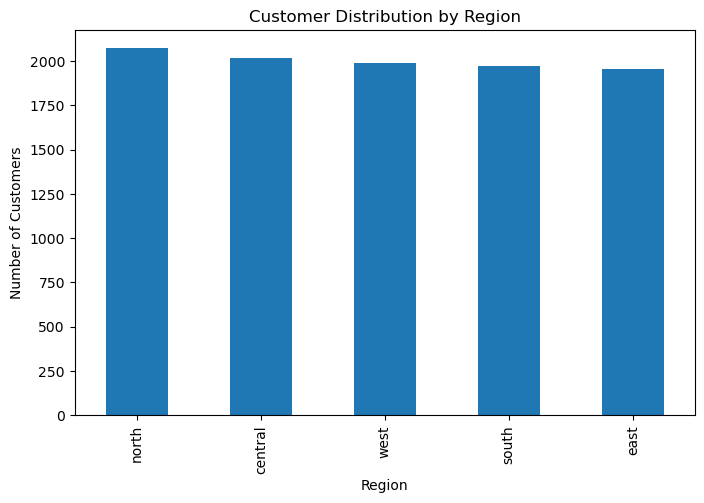

In [79]:
plt.figure(figsize=(8,5))
customer_master['region'].value_counts().plot(kind='bar')
plt.title('Customer Distribution by Region')
plt.xlabel('Region')
plt.ylabel('Number of Customers')
plt.show()

### Interpretation
The chart shows the distribution of customers across different regions. The north region having the highest customer count shows larger customer base and hence requires greater operational focus whereas the east region has the lowest customer count therefore needs more of marketing efforts.

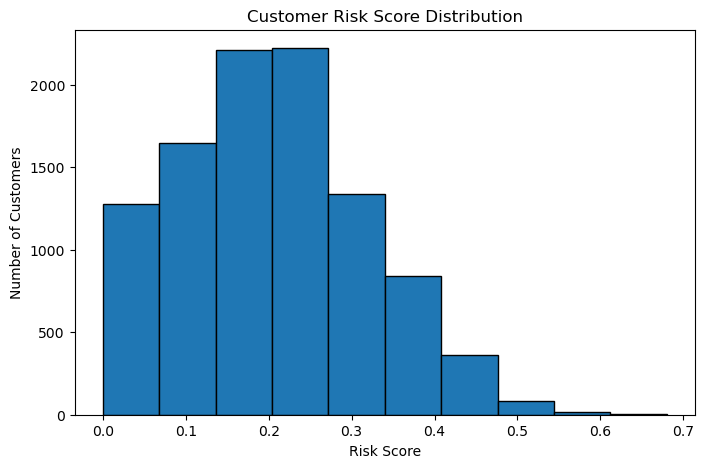

In [87]:
plt.figure(figsize=(8,5))
plt.hist(customer_master['risk_score'], bins=10, edgecolor='black')
plt.title('Customer Risk Score Distribution')
plt.xlabel('Risk Score')
plt.ylabel('Number of Customers')
plt.show()

### Interpretation
The distribution of customer risk scores helps identify whether most customers belong to low-risk, medium-risk, or high-risk categories, like a higher concentration of customers with elevated risk scores may indicate an increased likelihood of fraudulent activities or suspicious transaction behavior. These insights can assist financial institutions in prioritizing customer monitoring, strengthening fraud detection strategies and implementing appropriate risk-based security measures.

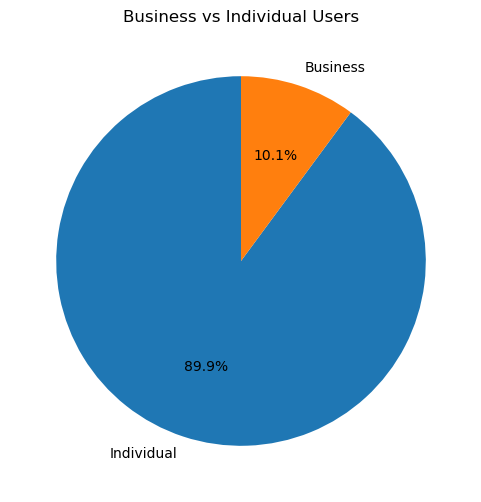

In [92]:
business_users = customer_master['is_business_user'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(
    business_users,
    labels=['Individual', 'Business'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Business vs Individual Users")
plt.show()

### Interpretation
The majority of users on the platform belong to either the individual. This helps the organization design customer-specific services, pricing strategies, and promotional campaigns tailored to each user segment.

<Figure size 800x500 with 0 Axes>

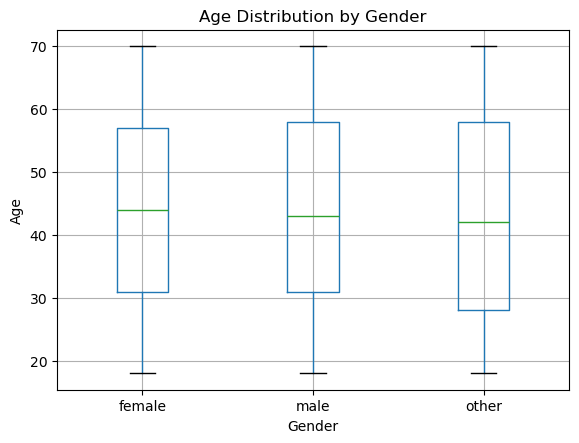

In [97]:
plt.figure(figsize=(8,5))
customer_master.boxplot(column='age', by='gender')
plt.title("Age Distribution by Gender")
plt.suptitle("")
plt.xlabel("Gender")
plt.ylabel("Age")
plt.show()

### Interpretation
The gender distribution provides an overview of the composition of the customer base using the UPI platform. This relatively balanced distribution indicates that the platform is widely adopted across different customer groups.

### TRANSACTION ANALYSIS

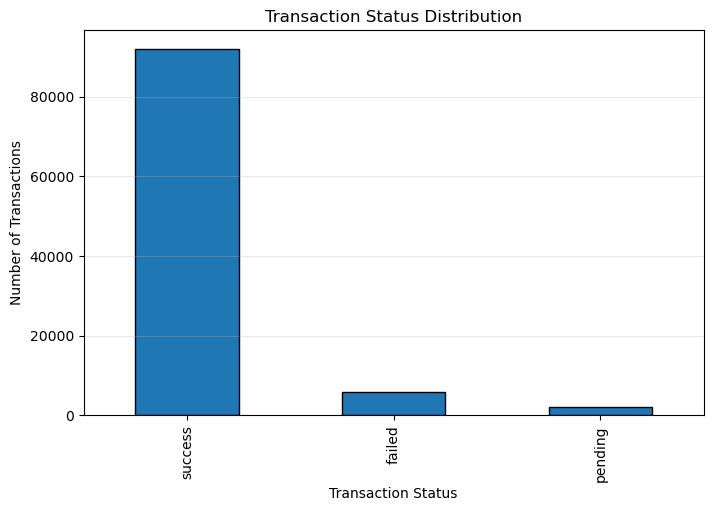

In [98]:
plt.figure(figsize=(8,5))
upi_transaction_history['status'].value_counts().plot(kind='bar',edgecolor='black')
plt.title("Transaction Status Distribution")
plt.xlabel("Transaction Status")
plt.ylabel("Number of Transactions")
plt.grid(axis='y', alpha=0.3)
plt.show()

### Interpretation
The chart shows the distribution of successful, failed, and pending transactions on the UPI platform. A higher proportion of successful transactions indicates strong operational reliability.

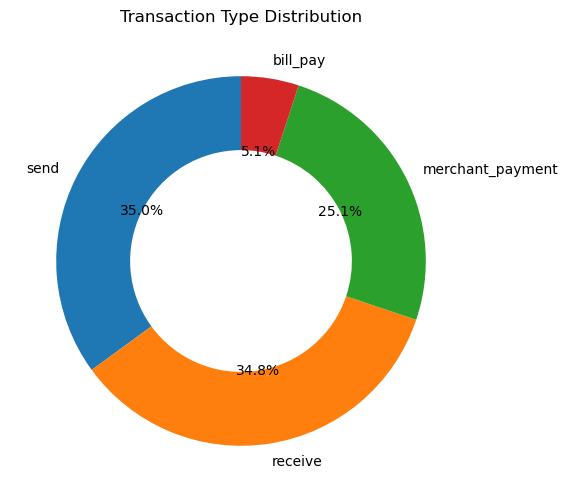

In [99]:
transaction_type = upi_transaction_history['transaction_type'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(
    transaction_type,
    labels=transaction_type.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width':0.4}
)
plt.title("Transaction Type Distribution")
plt.show()

### Interpretation
The transaction type distribution highlights customer payment preferences and usage patterns. Identifying the most frequently performed transaction types enables financial institutions to optimize services, improve user experience, and prioritize enhancements for the most commonly used payment feature which is sending money.

### MERCHANT ANALYSIS

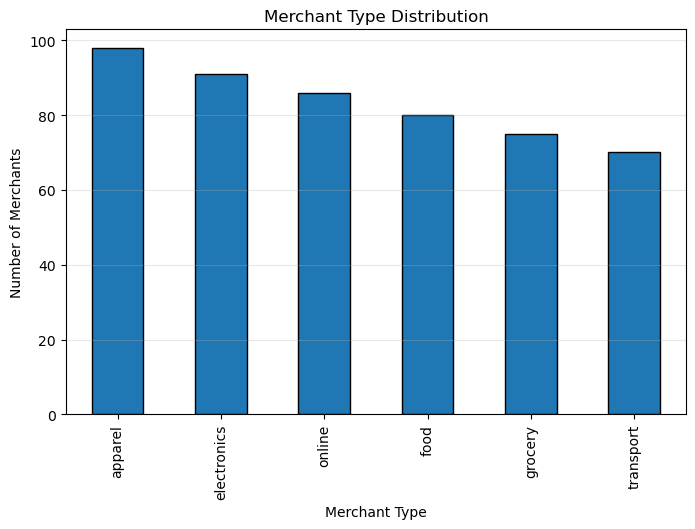

In [101]:
plt.figure(figsize=(8,5))
merchant_info['merchant_type'].value_counts().plot(kind='bar',edgecolor='black')
plt.title("Merchant Type Distribution")
plt.xlabel("Merchant Type")
plt.ylabel("Number of Merchants")
plt.grid(axis='y', alpha=0.3)
plt.show()

### Interpretation
The distribution of merchant categories provides an overview of the business sectors participating in the UPI ecosystem. The apparel sector indicate greatest platform adoption, while lesser categories present opportunities for targeted merchant onboarding and business expansion.

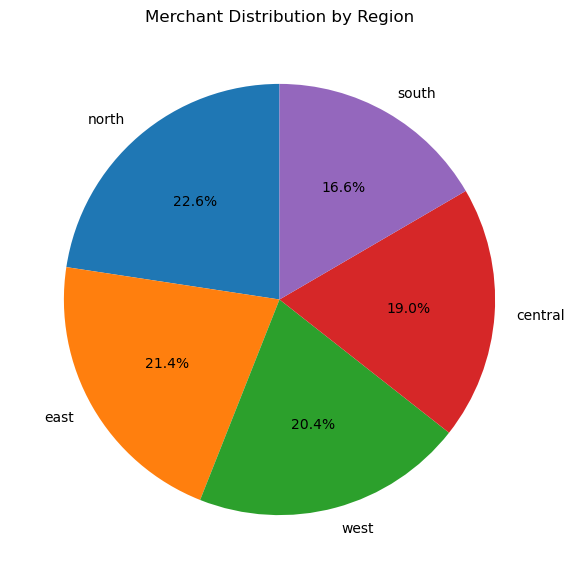

In [103]:
merchant_region = merchant_info['region'].value_counts()
plt.figure(figsize=(7,7))
plt.pie(merchant_region,labels=merchant_region.index,autopct='%1.1f%%',startangle=90)
plt.title("Merchant Distribution by Region")
plt.show()

### Interpretation
The regional distribution of merchants highlights areas with stronger merchant presence on the platform. The north region with higher concentration of merchants may generate greater transaction activity, while regions with fewer merchants like the south could benefit from targeted merchant acquisition and expansion initiatives.

### DEVICE ANALYTICS

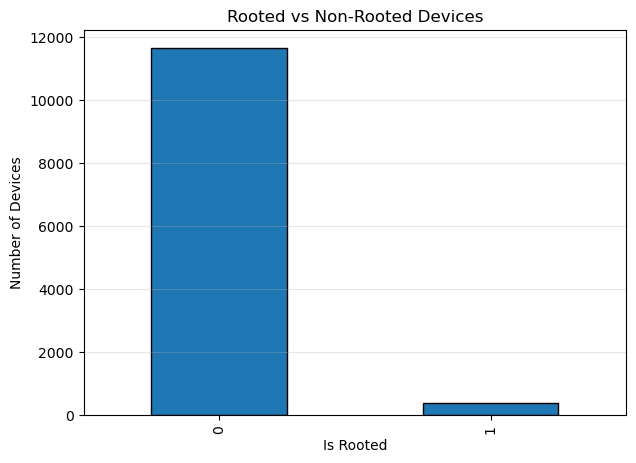

In [104]:
plt.figure(figsize=(7,5))
device_info['is_rooted'].value_counts().plot(kind='bar',edgecolor='black')
plt.title("Rooted vs Non-Rooted Devices")
plt.xlabel("Is Rooted")
plt.ylabel("Number of Devices")
plt.grid(axis='y', alpha=0.3)
plt.show()

### Interpretation
The majority of devices are non-rooted, indicating a relatively secure user base. Rooted devices present increased security vulnerabilities and can be considered higher-risk during fraud monitoring. Organizations use this information to strengthen authentication measures and apply additional verification for transactions originating from rooted devices.

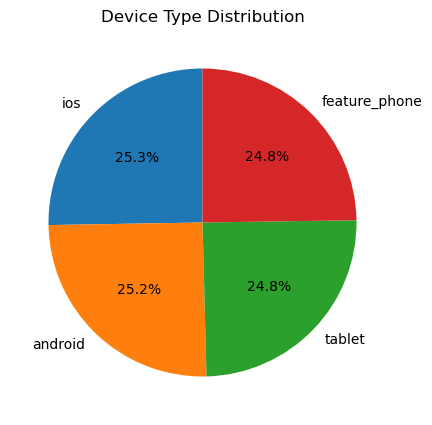

In [105]:
plt.figure(figsize=(8,5))
device_info['device_type'].value_counts().plot(kind='pie',autopct='%1.1f%%',startangle=90)
plt.title("Device Type Distribution")
plt.ylabel("")
plt.show()

### Interpretation
The distribution of device types provides insights into customer preferences for accessing UPI services. Understanding which devices are most frequently used enables organizations to prioritize application optimization, improve user experience, and ensure compatibility across popular platforms.

### FRAUD AND RISK ANALYSIS

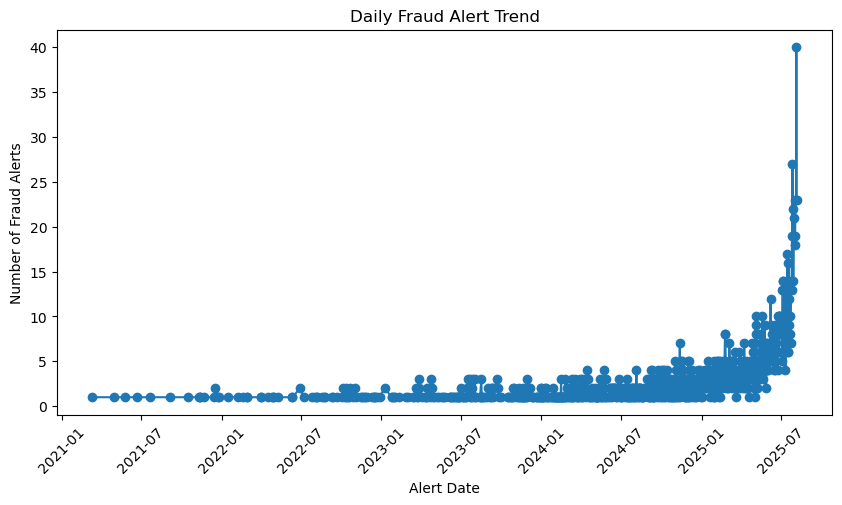

In [107]:
fraud_trend = fraud_alert_history_new['alert_date'].value_counts().sort_index()
plt.figure(figsize=(10,5))
plt.plot(fraud_trend.index,fraud_trend.values,marker='o')
plt.title("Daily Fraud Alert Trend")
plt.xlabel("Alert Date")
plt.ylabel("Number of Fraud Alerts")
plt.xticks(rotation=45)
plt.show()

### Interpretation
The daily fraud alert trend provides visibility into fluctuations in suspicious transaction activity over time. The peak in fraud alerts indicate periods of increased fraudulent behavior or security incidents, enabling financial institutions to strengthen monitoring, allocate investigative resources effectively and implement timely preventive measures.

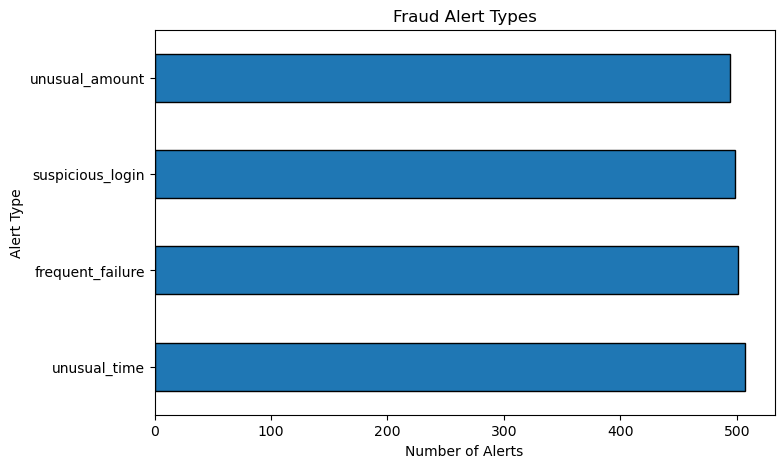

In [109]:
fraud_alert_history_new['alert_type'].value_counts().plot(kind='barh',figsize=(8,5),edgecolor='black')
plt.title("Fraud Alert Types")
plt.xlabel("Number of Alerts")
plt.ylabel("Alert Type")
plt.show()

### Interpretation
The distribution of fraud alert types highlights the most frequently detected fraudulent activities within the UPI ecosystem which in here is unusual time. Identifying this enables financial institutions to prioritize fraud prevention strategies, strengthen detection rules, and allocate resources toward the highest-risk threats.

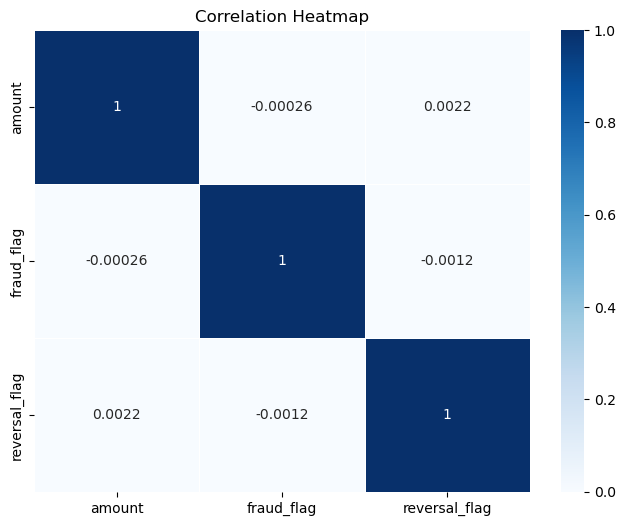

In [111]:
numeric_columns = upi_transaction_history.select_dtypes(include=np.number)
plt.figure(figsize=(8,6))
sns.heatmap(numeric_columns.corr(),annot=True,cmap="Blues",linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

## Statistical Analysis
The Exploratory Data Analysis (EDA) provided valuable insights into customer behavior, transaction patterns, merchant activities, device usage, and fraud trends through descriptive visualizations. These visualizations help identify patterns and potential relationships within the data.
To validate these observations, statistical analysis is performed in the next section using appropriate hypothesis testing techniques. These tests provide quantitative evidence to support decision-making.

In [112]:
upi_transaction_history['amount'].describe()

count    100000.000000
mean         42.417743
std          34.186004
min           1.620000
25%          20.690000
50%          33.090000
75%          53.170000
max         830.460000
Name: amount, dtype: float64

In [113]:
#INDEPENDENT SAMPLE T-TEST
from scipy.stats import ttest_ind
merged_data = upi_transaction_history.merge(device_info[['device_id', 'is_rooted']],on='device_id')
rooted = merged_data[merged_data['is_rooted'] == True]['amount']
non_rooted = merged_data[merged_data['is_rooted'] == False]['amount']
t_stat, p_value = ttest_ind(rooted, non_rooted)
print("T-Statistic :", t_stat)
print("P-Value :", p_value)

T-Statistic : -0.9259984243589916
P-Value : 0.3544490338072088


### Interpretation
Since the p-value is greater than the significance level of **0.05**, the null hypothesis cannot be rejected. Therefore, there is **no statistically significant difference** in the average transaction amount between transactions performed using rooted and non-rooted devices.

The statistical analysis indicates that the rooted status of a device does not significantly influence the average transaction amount in this dataset. Financial institutions should consider additional factors, such as transaction frequency, customer risk score, and fraud history, when assessing transaction risk.

In [116]:
from scipy.stats import f_oneway
merchant_transaction = upi_transaction_history.merge(
    merchant_info[['merchant_id', 'merchant_type']],
    on='merchant_id'
)
groups = []
for merchant in merchant_transaction['merchant_type'].unique():
    groups.append(
        merchant_transaction[
            merchant_transaction['merchant_type'] == merchant
        ]['amount']
    )
f_stat, p_value = f_oneway(*groups)
print("F-Statistic :", f_stat)
print("P-Value :", p_value)

F-Statistic : 0.9391677754562351
P-Value : 0.4541328025189961


### Interpretation
Since the p-value is greater than the significance level of **0.05**, the null hypothesis cannot be rejected. Therefore, there is **no statistically significant difference** in the average transaction amount across different merchant types in the dataset.

The analysis suggests that customers spend similar transaction amounts across different merchant categories. Merchant type alone does not appear to significantly influence transaction value. Therefore, financial institutions should consider additional factors such as customer demographics, transaction frequency, regional characteristics, or promotional campaigns when analyzing customer spending behavior.

In [117]:
from scipy.stats import chi2_contingency
contingency_table = pd.crosstab(
    upi_transaction_history['status'],
    upi_transaction_history['fraud_flag']
)
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print("Chi-Square Statistic :", chi2)
print("P-Value :", p_value)
print("Degrees of Freedom :", dof)

Chi-Square Statistic : 2.9554945123403686
P-Value : 0.22815107582983965
Degrees of Freedom : 2


### Interpretation
Since the p-value is greater than the significance level of **0.05**, the null hypothesis cannot be rejected. Therefore, there is **no statistically significant association** between transaction status and fraud occurrence in the dataset.

The statistical analysis suggests that transaction status and fraud occurrence are independent in this dataset. Fraudulent transactions are not significantly associated with a particular transaction status. Therefore, organizations should incorporate additional indicators such as device security and behavioral patterns when designing fraud detection models rather than relying solely on transaction status.

In [118]:
from scipy.stats import pearsonr
correlation_data = upi_transaction_history.merge(
    customer_master[['customer_id', 'risk_score']],
    on='customer_id'
)
correlation, p_value = pearsonr(
    correlation_data['risk_score'],
    correlation_data['amount']
)
print("Correlation Coefficient :", correlation)
print("P-Value :", p_value)

Correlation Coefficient : 0.0014487746691276722
P-Value : 0.64685380929071


### Interpretation
Since the p-value is greater than the significance level of **0.05**, the null hypothesis cannot be rejected. The correlation coefficient is very close to zero, indicating **no statistically significant linear relationship** between customer risk score and transaction amount.

The analysis indicates that customer risk score does not have a significant linear relationship with transaction amount in the current dataset. Customers with higher risk scores do not necessarily perform higher-value transactions. Therefore, transaction amount alone should not be considered a reliable indicator of customer risk. Financial institutions should incorporate additional factors such as fraud history and behavioral patterns to develop more effective fraud detection and risk assessment models.